In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))


In [10]:
import importlib
import src.track_a
importlib.reload(src.track_a)

results = src.track_a.run()
results

logreg_C1_none               val_macro_f1=0.8618 acc=0.8587 (5.1s)
logreg_C1_bal                val_macro_f1=0.8611 acc=0.8573 (4.4s)
logreg_C3_none               val_macro_f1=0.8841 acc=0.8818 (6.2s)
logreg_C3_bal                val_macro_f1=0.8844 acc=0.8811 (5.3s)
logreg_C10_none              val_macro_f1=0.8931 acc=0.8902 (8.4s)
logreg_C10_bal               val_macro_f1=0.8968 acc=0.8937 (6.9s)
logreg_C30_none              val_macro_f1=0.8900 acc=0.8867 (7.2s)
logreg_C30_bal               val_macro_f1=0.8937 acc=0.8909 (4.7s)
logreg_C100_none             val_macro_f1=0.8905 acc=0.8874 (5.6s)
logreg_C100_bal              val_macro_f1=0.8883 acc=0.8853 (15.0s)
linsvc_calibrated            val_macro_f1=0.8815 acc=0.8783 (2.0s)

selected: logreg_C10_bal  |  vocabulary size: 9055
TEST in-scope: macro_f1=0.8896 acc=0.8896


,model,fit_seconds,accuracy,macro_f1,weighted_f1
5,logreg_C10_bal,6.95,0.893706,0.896769,0.893616
7,logreg_C30_bal,4.70,0.890909,0.893702,0.890718
4,logreg_C10_none,8.40,0.890210,0.893074,0.890098
8,logreg_C100_none,5.56,0.887413,0.890472,0.887231
6,logreg_C30_none,7.23,0.886713,0.890041,0.886522
9,logreg_C100_bal,14.99,0.885315,0.888266,0.885325
3,logreg_C3_bal,5.28,0.881119,0.884387,0.881163
2,logreg_C3_none,6.19,0.881818,0.884129,0.881678
10,linsvc_calibrated,1.97,0.878322,0.881516,0.878157
0,logreg_C1_none,5.08,0.858741,0.861805,0.859035


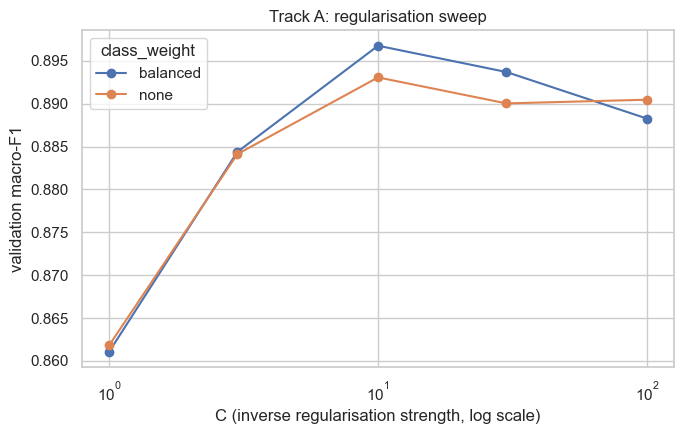

In [11]:
import matplotlib.pyplot as plt
from src import config

df = results[results["model"].str.startswith("logreg")].copy()
df["C"] = df["model"].str.extract(r"C(\d+)").astype(float)
df["weighting"] = df["model"].str.endswith("bal").map({True: "balanced", False: "none"})

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, grp in df.groupby("weighting"):
    grp = grp.sort_values("C")
    ax.plot(grp["C"], grp["macro_f1"], marker="o", label=label)

ax.set_xscale("log")
ax.set_xlabel("C (inverse regularisation strength, log scale)")
ax.set_ylabel("validation macro-F1")
ax.set_title("Track A: regularisation sweep")
ax.legend(title="class_weight")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "track_a_regularisation.png", dpi=150)
plt.show()